In [1]:
%run shared_imports.py

In [2]:
engine = make_engine("settings.toml")
session = Session(engine)

In [3]:
query = session.query(Feedback.json).join(Round).filter(
        Feedback.key_name == "cargo salvage sold",
        Round.start_datetime >= datetime(2024, 8, 1),
        Round.start_datetime < datetime(2024, 10, 1))

prod_salvage_sold = pd.read_sql_query(query.statement, session.connection())

In [4]:
prod_salvage_sold

,json
0,"{'data': {'stolen jewellery': {'count': 7, 'cr..."
1,"{'data': {'stolen jewellery': {'count': 3, 'cr..."
2,"{'data': {'rum keg': {'count': 1, 'credits': 1..."
3,"{'data': {'lost research notes': {'count': 1, ..."
4,"{'data': {'stolen jewellery': {'count': 2, 'cr..."
...,...
394,"{'data': {'stolen jewellery': {'count': 3, 'cr..."
395,"{'data': {'mysterious tablet': {'count': 2, 'c..."
396,"{'data': {'rum keg': {'count': 2, 'credits': 2..."
397,"{'data': {'stolen jewellery': {'count': 9, 'cr..."


In [24]:
def json_to_series(text):
    credits = [item['credits'] for item in text['data'].values()]
    return pd.Series([sum(credits)], index=['Credits'])

In [26]:
credits = pd.concat([prod_salvage_sold, prod_salvage_sold['json'].apply(json_to_series)], axis=1).drop(['json'], axis=1)

In [42]:
credits.Credits.min()

100

In [27]:
sns.set_theme()

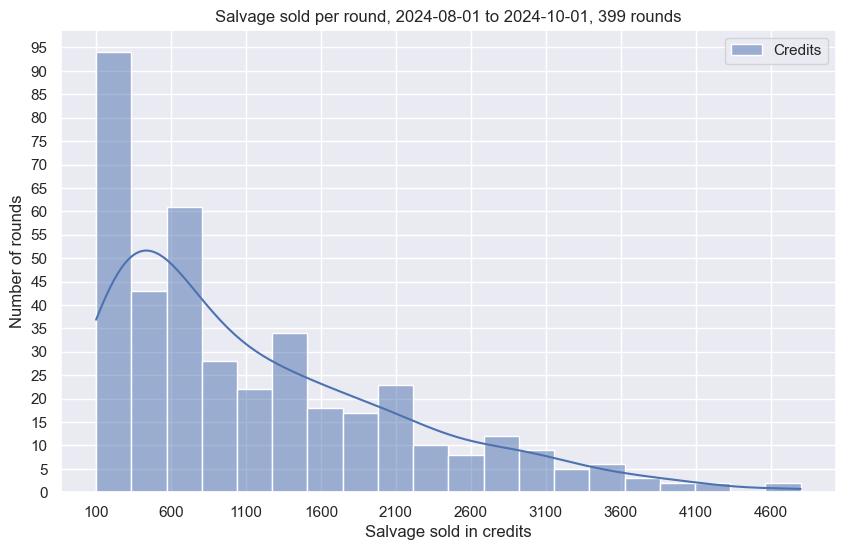

In [50]:
fig, ax = plt.subplots()
fig.set_size_inches(10, 6)

ax.locator_params(axis='x', integer=True)
ax.set(title='Salvage sold per round, 2024-08-01 to 2024-10-01, 399 rounds')
ax.yaxis.set_ticks(np.arange(0, 100, 5))
ax.set_xlabel("Salvage sold in credits")
ax.set_ylabel("Number of rounds")

ax.xaxis.set_ticks(np.arange(100, credits.Credits.max(), 500))
sns.histplot(credits, multiple='dodge', kde=True, bins=20)
plt.savefig('salvage_sold_2024-08-01_2024-10-01.png')